# Fingo DS1 — Impulsive Transaction Detector
## Data Wrangling, EDA, Feature Engineering & A/B Testing Pipeline
---
### Alur Notebook
```
Bagian 0 : Setup & Clone GitHub
Bagian 1 : Gathering Data
Bagian 2 : Assessing Data
Bagian 3 : Cleaning Data
Bagian 4 : Feature Engineering
Bagian 5 : Generate Data Sintetis & Merge
Bagian 6 : Impulsive Labeling (Rule-Based Heuristic)
Bagian 7 : Exploratory Data Analysis (BQ1–BQ3)
Bagian 8 : A/B Testing
Bagian 9 : Bias Testing & Validasi Data Sintetis
Bagian 10: Normalisasi & Export CSV
Bagian 11: Data Dictionary
Bagian 12: Push ke GitHub
```


## Bagian 0 — Setup & Clone GitHub

In [ ]:
# ============================================================
# GLOBAL IMPORTS & KONSTANTA
# ============================================================
import os
import re
import warnings
import subprocess
import pickle
from pathlib import Path
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from faker import Faker
from scipy import stats
from scipy.stats import ttest_ind, ttest_rel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

# ── Paths ────────────────────────────────────────────────────
BASE_DIR       = Path('/content/fingo-impulsive-detector')
DATA_RAW       = BASE_DIR / 'data' / 'raw'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
OUTPUTS        = BASE_DIR / 'outputs'
CHARTS         = OUTPUTS / 'charts'
NOTEBOOKS_DIR  = BASE_DIR / 'notebooks'

for p in [DATA_RAW, DATA_PROCESSED, OUTPUTS, CHARTS, NOTEBOOKS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ── Konversi Mata Uang (per May 2026) ─────────────────────
USD_TO_IDR = 17_544
INR_TO_IDR = 183

# ── Konfigurasi Impulsive Labeling ──────────────────────────
W_NIGHT          = 0.35   # Bobot waktu malam
W_CATEGORY       = 0.30   # Bobot kategori hedonic
W_AMOUNT         = 0.25   # Bobot nilai transaksi
W_WEEKEND        = 0.10   # Bobot akhir pekan
LABEL_IMPULSIF      = 0.90  # Quantile atas → IMPULSIF
LABEL_PERTIMBANGAN  = 0.70  # Quantile tengah → PERTIMBANGAN

# ── Kategori ────────────────────────────────────────────────
HEDONIC_CATEGORIES  = {'Hiburan', 'Belanja'}
NEUTRAL_CATEGORIES  = {'Makanan', 'Transportasi', 'Lainnya'}
UTIL_CATEGORIES     = {'Pendidikan', 'Kesehatan', 'Tagihan'}

# ── Warna Fingo ─────────────────────────────────────────────
FINGO_COLORS = {
    'primary' : '#4F46E5',   # indigo
    'success' : '#22C55E',   # hijau
    'warning' : '#F59E0B',   # kuning
    'danger'  : '#EF4444',   # merah
    'neutral' : '#6B7280',   # abu-abu
}

# ── Style global matplotlib ──────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

print('Setup selesai ✓')
print(f'BASE_DIR : {BASE_DIR}')


## Bagian 1 — Gathering Data

### Sumber Dataset
| No | Dataset | Sumber | Jumlah Baris | Digunakan untuk |
|----|---------|--------|--------------|-----------------|
| 1 | Personal Finance Dataset (Synthetic) | Kaggle | 1.500 | Pola transaksi, mapping kategori |
| 2 | Daily Household Transactions | Kaggle | 2.461 | Timestamp detail, hour_sin/cos (INR) |
| 3 | Indonesia E-Commerce Sales 2023–2025 | Kaggle | 20.000+ | Timestamp Indonesia, pola waktu |
| 4 | Data Sintetis (NumPy + Faker) | Tim Fingo | ~5.000 | Augmentasi, pola gig worker Indonesia |

> **Catatan:** Dataset Mendeley (BNPL Indonesia IBB score) dapat ditambahkan jika tersedia di `data/raw/Raw_Data_Paylater.csv`.  
> Proporsi data sintetis vs asli didokumentasikan di Bagian 10.


In [ ]:
# ── Dataset 1: Personal Finance Dataset (Kaggle) ──────────────
# Kaggle: https://www.kaggle.com/datasets/abhishekrp1517/personal-finance-dataset
# File: Personal_Finance_Dataset.csv
# 5 kolom: Date, Transaction Description, Category, Amount, Type
# Amount dalam USD → dikonversi ke IDR

RAW_PERSONAL = DATA_RAW / 'Personal_Finance_Dataset.csv'

if RAW_PERSONAL.exists():
    df_personal = pd.read_csv(RAW_PERSONAL)
    print(f'Dataset 1 (Personal Finance) dimuat: {df_personal.shape}')
    display(df_personal.head(3))
else:
    print(f'File tidak ditemukan: {RAW_PERSONAL}')
    print('Upload ke: data/raw/Personal_Finance_Dataset.csv')
    df_personal = None


In [ ]:
# ── Dataset 2: Daily Household Transactions (Kaggle) ─────────
# Kaggle: https://www.kaggle.com/datasets/apoorvwatsky/bank-transaction-data
# File: Daily Household Transactions.csv
# 8 kolom: Date, Mode, Category, Subcategory, Note, Amount, Income/Expense, Currency
# Amount dalam INR (India Rupee) → dikonversi ke IDR
# Timestamp sangat detail (DD/MM/YYYY HH:MM:SS) — berguna untuk hour_sin/cos

RAW_DAILY = DATA_RAW / 'Daily Household Transactions.csv'

if RAW_DAILY.exists():
    df_daily = pd.read_csv(RAW_DAILY)
    print(f'Dataset 2 (Daily Transactions) dimuat: {df_daily.shape}')
    display(df_daily.head(3))
else:
    print(f'File tidak ditemukan: {RAW_DAILY}')
    df_daily = None


In [ ]:
# ── Dataset 3: Indonesia E-Commerce Sales 2023–2025 (Kaggle) ─
# Kaggle: Indonesia E-Commerce Sales & Shipping 2023-2025
# File: all_months_clean.csv (separator ;)
# Kolom kunci: Waktu Pesanan Dibuat, Total Pembayaran, product_categories
# Timestamp Indonesia terbaik untuk analisis pola waktu (hour_sin/cos)

RAW_ECOMMERCE = DATA_RAW / 'all_months_clean.csv'

if RAW_ECOMMERCE.exists():
    df_ecommerce = pd.read_csv(RAW_ECOMMERCE, sep=';')
    print(f'Dataset 3 (E-Commerce Indonesia) dimuat: {df_ecommerce.shape}')
    print(f'Kolom: {df_ecommerce.columns.tolist()}')
    display(df_ecommerce[['Waktu Pesanan Dibuat', 'Total Pembayaran', 'product_categories']].head(3))
else:
    print(f'File tidak ditemukan: {RAW_ECOMMERCE}')
    print('Upload ke: data/raw/all_months_clean.csv')
    df_ecommerce = None

# ── Dataset 4 (Opsional): Mendeley BNPL Indonesia ─────────────
# Ground-truth terkuat untuk labeling impulsif lokal Indonesia
RAW_PAYLATER = DATA_RAW / 'Raw_Data_Paylater.csv'

if RAW_PAYLATER.exists():
    df_paylater = pd.read_csv(RAW_PAYLATER, sep=';', encoding='latin-1')
    print(f'\nDataset 4 (Mendeley BNPL) dimuat: {df_paylater.shape}')
    display(df_paylater.head(3))
else:
    print('\nDataset Mendeley tidak tersedia — akan menggunakan rule-based labeling.')
    df_paylater = None


## Bagian 2 — Assessing Data

In [ ]:
def assess_dataset(df: pd.DataFrame, name: str) -> Dict:
    """Evaluasi kualitas dataset: shape, dtype, missing, duplikat, outlier amount."""
    print(f'\n{"="*60}')
    print(f'DATASET: {name}')
    print(f'{"="*60}')
    print(f'Shape         : {df.shape}')
    print(f'Kolom         : {list(df.columns)}')
    print(f'Duplikat      : {df.duplicated().sum()}')

    miss     = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    miss_df  = pd.DataFrame({'Missing': miss, 'Pct (%)': miss_pct})
    miss_df  = miss_df[miss_df['Missing'] > 0]
    if not miss_df.empty:
        print('\nMissing Values:')
        print(miss_df.to_string())
    else:
        print('Missing Values : Tidak ada')

    num_cols = df.select_dtypes(include='number').columns
    if len(num_cols):
        print('\nStatistik Numerik:')
        print(df[num_cols].describe().round(2).to_string())

    print(f'\nDtype per kolom:')
    print(df.dtypes.to_string())

    return {
        'name'       : name,
        'rows'       : df.shape[0],
        'cols'       : df.shape[1],
        'duplicates' : df.duplicated().sum(),
        'missing_pct': miss_pct.max(),
    }


summary_list = []
if df_personal is not None:
    summary_list.append(assess_dataset(df_personal, 'Personal Finance Dataset'))
if df_daily is not None:
    summary_list.append(assess_dataset(df_daily, 'Daily Household Transactions'))
if df_ecommerce is not None:
    summary_list.append(assess_dataset(df_ecommerce, 'Indonesia E-Commerce 2023-2025'))
if df_paylater is not None:
    summary_list.append(assess_dataset(df_paylater, 'Mendeley BNPL Indonesia'))


In [ ]:
# Ringkasan semua dataset dalam satu tabel
if summary_list:
    df_summary = pd.DataFrame(summary_list)
    print('\n' + '='*50)
    print('RINGKASAN KUALITAS DATASET')
    print('='*50)
    display(df_summary)


## Bagian 3 — Cleaning Data

Proses cleaning:
1. Standarisasi kolom nama
2. Parsing timestamp (multi-format)
3. Konversi mata uang (USD/INR → IDR)
4. Filter Expense only
5. Mapping kategori ke 8 GigFlow standar
6. Drop duplikat & nilai ekstrem
7. Drop kategori non-relevan (investasi, tabungan, dll.)


In [ ]:
# ── Mapping kategori ke 8 GigFlow standar ────────────────────
CATEGORY_MAP: Dict[str, str] = {
    # Makanan
    'food & drink'  : 'Makanan', 'food'       : 'Makanan',
    'grocery'       : 'Makanan', 'groceries'  : 'Makanan',
    'restaurant'    : 'Makanan', 'snacks'     : 'Makanan',
    # Transportasi
    'transportation': 'Transportasi', 'travel'   : 'Transportasi',
    'transport'     : 'Transportasi', 'commute'  : 'Transportasi',
    'train'         : 'Transportasi', 'bus'      : 'Transportasi',
    # Hiburan
    'entertainment' : 'Hiburan', 'subscription': 'Hiburan',
    'movies'        : 'Hiburan', 'gaming'      : 'Hiburan',
    'culture'       : 'Hiburan', 'festivals'   : 'Hiburan',
    'tourism'       : 'Hiburan', 'social life' : 'Hiburan',
    # Belanja
    'shopping'      : 'Belanja', 'apparel'     : 'Belanja',
    'clothing'      : 'Belanja', 'beauty'      : 'Belanja',
    'grooming'      : 'Belanja', 'household'   : 'Belanja',
    'gift'          : 'Belanja',
    # Pendidikan
    'education'     : 'Pendidikan', 'self-development': 'Pendidikan',
    # Kesehatan
    'health & fitness': 'Kesehatan', 'health' : 'Kesehatan',
    'fitness'       : 'Kesehatan',   'medical': 'Kesehatan',
    # Tagihan
    'utilities'     : 'Tagihan', 'rent'    : 'Tagihan',
    'bills'         : 'Tagihan', 'mobile service provider': 'Tagihan',
    'water'         : 'Tagihan', 'internet': 'Tagihan',
    'electricity'   : 'Tagihan', 'phone'   : 'Tagihan',
}

# Kategori yang di-drop (non-konsumsi)
DROP_CATEGORIES = {'ppf', 'equity mutual fund', 'mutual fund',
                   'investment', 'savings', 'insurance', 'tax'}

def map_category(raw: str) -> str:
    """Map kategori raw ke 8 GigFlow standar."""
    if not isinstance(raw, str):
        return 'Lainnya'
    key = raw.strip().lower()
    return CATEGORY_MAP.get(key, 'Lainnya')

print('Category map siap ✓')
print(f'Mapping terdaftar: {len(CATEGORY_MAP)} entri → 8 kategori standar')


In [ ]:
def clean_personal_finance(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    """
    Cleaning Dataset 1 — Personal Finance Dataset
    - Filter Expense saja
    - Parse Date
    - Konversi Amount USD → IDR
    - Map Category ke 8 GigFlow standar
    - Drop duplikat
    """
    if df is None:
        return None

    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # Filter expense only
    df = df[df['type'].str.lower() == 'expense'].copy()

    # Parse date
    df['timestamp'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['timestamp'])

    # Konversi USD → IDR
    df['amount'] = pd.to_numeric(df['amount'], errors='coerce') * USD_TO_IDR
    df = df.dropna(subset=['amount'])
    df = df[df['amount'] > 0]

    # Map category
    df['category'] = df['category'].apply(map_category)

    # Tambah kolom sumber
    df['source'] = 'kaggle_personal_finance'

    result = df[['timestamp', 'amount', 'category', 'source']].drop_duplicates().reset_index(drop=True)
    print(f'clean_personal_finance: {result.shape[0]:,} baris setelah cleaning')
    return result


df_personal_clean = clean_personal_finance(df_personal)
if df_personal_clean is not None:
    display(df_personal_clean.head(3))
    print(f'Category distribution:\n{df_personal_clean["category"].value_counts().to_string()}')


In [ ]:
def clean_daily_transactions(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    """
    Cleaning Dataset 2 — Daily Household Transactions
    - Filter Expense saja
    - Parse timestamp multi-format (beberapa baris tidak punya jam)
    - Konversi Amount INR → IDR
    - Map Category ke 8 GigFlow standar
    - Drop kategori investasi/tabungan
    - Drop duplikat
    """
    if df is None:
        return None

    df = df.copy()
    df.columns = df.columns.str.strip()

    # Filter expense only
    ie_col = next((c for c in df.columns if 'income' in c.lower()), None)
    if ie_col:
        df = df[df[ie_col].str.lower() == 'expense'].copy()

    # Drop kategori non-relevan
    if 'Category' in df.columns:
        df = df[~df['Category'].str.lower().isin(DROP_CATEGORIES)].copy()

    # Parse timestamp multi-format
    def parse_ts(val: str) -> pd.Timestamp:
        for fmt in ('%d/%m/%Y %H:%M:%S', '%d/%m/%Y', '%Y-%m-%d %H:%M:%S', '%Y-%m-%d'):
            try:
                return pd.to_datetime(val, format=fmt)
            except Exception:
                pass
        return pd.NaT

    df['timestamp'] = df['Date'].apply(parse_ts)
    df = df.dropna(subset=['timestamp'])

    # Baris tanpa jam → asumsi jam 12:00 (siang hari, netral)
    no_time_mask = df['timestamp'].dt.hour == 0
    df.loc[no_time_mask, 'timestamp'] = (
        df.loc[no_time_mask, 'timestamp'] + pd.Timedelta(hours=12)
    )

    # Konversi INR → IDR
    df['amount'] = pd.to_numeric(df['Amount'], errors='coerce') * INR_TO_IDR
    df = df.dropna(subset=['amount'])
    df = df[df['amount'] > 0]

    # Map category
    df['category'] = df['Category'].apply(map_category)
    df['source']   = 'kaggle_daily_transactions'

    result = df[['timestamp', 'amount', 'category', 'source']].drop_duplicates().reset_index(drop=True)
    print(f'clean_daily_transactions: {result.shape[0]:,} baris setelah cleaning')
    return result


df_daily_clean = clean_daily_transactions(df_daily)
if df_daily_clean is not None:
    display(df_daily_clean.head(3))
    print(f'Timestamp range: {df_daily_clean["timestamp"].min()} → {df_daily_clean["timestamp"].max()}')


In [ ]:
def clean_ecommerce(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    """
    Cleaning Dataset 3 — Indonesia E-Commerce 2023–2025
    - Filter status 'Selesai' (transaksi berhasil)
    - Parse timestamp Indonesia
    - Gunakan Total Pembayaran sebagai amount (IDR)
    - Map product_categories ke 8 GigFlow standar
    - Fokus: mendapat timestamp Indonesia yang kaya untuk hour_sin/cos
    """
    if df is None:
        return None

    df = df.copy()

    # Filter status selesai saja
    if 'Status Pesanan' in df.columns:
        df = df[df['Status Pesanan'] == 'Selesai'].copy()

    # Parse timestamp
    df['timestamp'] = pd.to_datetime(df['Waktu Pesanan Dibuat'], errors='coerce', format='%Y-%m-%d %H:%M')
    if df['timestamp'].isna().all():
        df['timestamp'] = pd.to_datetime(df['Waktu Pesanan Dibuat'], errors='coerce')
    df = df.dropna(subset=['timestamp'])

    # Amount dari Total Pembayaran (sudah IDR)
    df['amount'] = pd.to_numeric(
        df['Total Pembayaran'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df = df.dropna(subset=['amount'])
    df = df[df['amount'] > 0]

    # Map product categories
    ECOM_CAT_MAP = {
        'fashion'       : 'Belanja', 'pakaian'     : 'Belanja',
        'elektronik'    : 'Belanja', 'gadget'      : 'Belanja',
        'makanan'       : 'Makanan', 'food'        : 'Makanan',
        'minuman'       : 'Makanan', 'kesehatan'   : 'Kesehatan',
        'kecantikan'    : 'Belanja', 'beauty'      : 'Belanja',
        'olahraga'      : 'Kesehatan','hiburan'    : 'Hiburan',
        'mainan'        : 'Hiburan', 'buku'        : 'Pendidikan',
        'perlengkapan rumah': 'Tagihan',
    }

    def map_ecom_cat(raw):
        if not isinstance(raw, str):
            return 'Belanja'  # default e-commerce = Belanja
        key = raw.lower().strip()
        for k, v in ECOM_CAT_MAP.items():
            if k in key:
                return v
        return 'Belanja'

    df['category'] = df['product_categories'].apply(map_ecom_cat)
    df['source']   = 'kaggle_ecommerce_id'

    result = df[['timestamp', 'amount', 'category', 'source']].drop_duplicates().reset_index(drop=True)
    print(f'clean_ecommerce: {result.shape[0]:,} baris setelah cleaning')
    return result


df_ecommerce_clean = clean_ecommerce(df_ecommerce)
if df_ecommerce_clean is not None:
    display(df_ecommerce_clean.head(3))
    print(f'Timestamp range: {df_ecommerce_clean["timestamp"].min()} → {df_ecommerce_clean["timestamp"].max()}')
    print(f'Category distribution:\n{df_ecommerce_clean["category"].value_counts().to_string()}')


## Bagian 4 — Feature Engineering

Fitur yang dibuat:
| Fitur | Tipe | Deskripsi |
|-------|------|-----------|
| `hour` | int | Jam transaksi (0–23) |
| `hour_sin` | float | Encoding siklus jam — sin(2π×h/24) |
| `hour_cos` | float | Encoding siklus jam — cos(2π×h/24) |
| `day_of_week` | int | Hari dalam minggu (0=Senin) |
| `is_weekend` | int | 1 jika Sabtu/Minggu |
| `is_night` | int | 1 jika jam 20:00–03:59 |
| `night_score` | float | Skor malam gradual (1=tengah malam, 0=siang) |
| `category_score` | float | 1=hedonic, 0.5=neutral, 0=utilitarian |
| `amount_z` | float | Z-score nilai transaksi per dataset |
| `amount_score` | float | Normalisasi amount_z ke 0–1 |
| `amount_vs_weekly_avg` | float | Rasio amount terhadap rata-rata mingguan user |
| `budget_remaining_ratio` | float | Estimasi sisa budget (sintetis, 0–1) |


In [ ]:
def engineer_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Ekstraksi dan encoding fitur waktu dari kolom timestamp."""
    df = df.copy()

    df['hour']        = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Senin, 6=Minggu
    df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

    # Encoding siklus sin/cos agar jam 23 & jam 0 berdekatan
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Biner malam (20–03)
    df['is_night'] = df['hour'].apply(lambda h: 1 if (h >= 20 or h <= 3) else 0)

    # Skor malam gradual (puncak tengah malam, 0 di siang hari)
    circ_dist         = np.minimum(df['hour'], 24 - df['hour'])
    df['night_score'] = 1 - (circ_dist / 12)  # range [0, 1]

    return df


def engineer_category_features(df: pd.DataFrame) -> pd.DataFrame:
    """Buat category_score berdasarkan tipe belanja hedonic vs utilitarian."""
    df = df.copy()

    def cat_score(cat: str) -> float:
        if cat in HEDONIC_CATEGORIES:
            return 1.0
        elif cat in NEUTRAL_CATEGORIES:
            return 0.5
        else:   # UTIL_CATEGORIES atau Lainnya
            return 0.0

    df['category_score'] = df['category'].apply(cat_score)
    return df


def engineer_amount_features(df: pd.DataFrame) -> pd.DataFrame:
    """Z-score amount per source dan normalisasi ke amount_score."""
    df = df.copy()

    # Z-score per source untuk menangkap outlier relatif
    df['amount_z'] = (
        df.groupby('source', group_keys=False)['amount']
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
    )

    # Clamp ke [-3, 3] lalu scale ke [0, 1]
    df['amount_z']     = df['amount_z'].clip(-3, 3)
    df['amount_score'] = (df['amount_z'] + 3) / 6

    return df


def engineer_context_features(df: pd.DataFrame) -> pd.DataFrame:
    """Fitur konteks finansial: rasio terhadap rata-rata mingguan & sisa budget."""
    df = df.copy()

    # ── amount_vs_weekly_avg ──────────────────────────────────
    # Rata-rata pengeluaran per user per minggu
    df['year_week'] = df['timestamp'].dt.isocalendar().year.astype(str) + '_' + \
                      df['timestamp'].dt.isocalendar().week.astype(str).str.zfill(2)

    # Proxy user_id jika belum ada
    if 'user_id' not in df.columns:
        df['user_id'] = 'all'

    weekly_avg = (
        df.groupby(['user_id', 'year_week'])['amount']
        .transform('mean')
    )
    df['amount_vs_weekly_avg'] = (df['amount'] / (weekly_avg + 1e-9)).clip(0, 5)

    # ── budget_remaining_ratio ───────────────────────────────
    # Estimasi: di awal bulan = penuh (1.0), di akhir bulan = rendah (0.1)
    day_of_month = df['timestamp'].dt.day
    days_in_month = df['timestamp'].dt.days_in_month
    budget_consumed = day_of_month / days_in_month   # 0–1
    df['budget_remaining_ratio'] = (1 - budget_consumed).clip(0.05, 1.0)

    return df


print('Fungsi feature engineering siap ✓')


## Bagian 5 — Generate Data Sintetis & Merge

Data sintetis dibuat untuk:
1. Menambah volume dataset (target ~5.000 baris total)
2. Representasi pola impulsif khas **gig worker Indonesia**:
   - Transaksi malam hari (ojek online selesai kerja, jam 20–23)
   - Belanja akhir bulan (baru gajian)
   - Kategori Hiburan & Belanja dengan nilai di atas rata-rata
3. Validasi: proporsi sintetis vs asli didokumentasikan di Bagian 10


In [ ]:
def generate_synthetic_transactions(
    n_users    : int = 200,
    n_per_user : int = 25,
    seed       : int = 42,
) -> pd.DataFrame:
    """
    Generate data sintetis transaksi gig worker Indonesia.

    Parameters
    ----------
    n_users     : jumlah user sintetis
    n_per_user  : jumlah transaksi per user
    seed        : random seed

    Returns
    -------
    DataFrame dengan kolom: timestamp, amount, category, source, user_id, gig_type
    """
    rng_s  = np.random.default_rng(seed)
    fake   = Faker('id_ID')
    Faker.seed(seed)

    GIG_DIST = {
        'ojek_online': 0.35,
        'freelancer' : 0.25,
        'reseller'   : 0.20,
        'part_time'  : 0.20,
    }
    gig_types = list(GIG_DIST.keys())
    gig_props = list(GIG_DIST.values())

    # Distribusi kategori per gig type (mencerminkan pola hidup gig worker)
    CAT_DIST_BY_GIG = {
        'ojek_online': {'Makanan': 0.30, 'Transportasi': 0.25, 'Belanja': 0.20,
                        'Hiburan': 0.15, 'Tagihan': 0.05, 'Lainnya': 0.05},
        'freelancer' : {'Makanan': 0.25, 'Belanja': 0.25, 'Hiburan': 0.20,
                        'Pendidikan': 0.15, 'Transportasi': 0.10, 'Tagihan': 0.05},
        'reseller'   : {'Belanja': 0.35, 'Makanan': 0.20, 'Transportasi': 0.20,
                        'Tagihan': 0.10, 'Lainnya': 0.10, 'Hiburan': 0.05},
        'part_time'  : {'Makanan': 0.30, 'Hiburan': 0.25, 'Belanja': 0.20,
                        'Transportasi': 0.15, 'Kesehatan': 0.05, 'Tagihan': 0.05},
    }

    # Range amount per kategori (IDR)
    AMOUNT_RANGE = {
        'Makanan'     : (15_000,  150_000),
        'Transportasi': (5_000,   75_000),
        'Hiburan'     : (25_000,  500_000),
        'Belanja'     : (50_000,  800_000),
        'Pendidikan'  : (100_000, 2_000_000),
        'Kesehatan'   : (30_000,  500_000),
        'Tagihan'     : (50_000,  500_000),
        'Lainnya'     : (10_000,  200_000),
    }

    records = []
    for u in range(n_users):
        user_id  = f'SYN_{u:04d}'
        gig_type = rng_s.choice(gig_types, p=gig_props)
        cat_dist = CAT_DIST_BY_GIG[gig_type]
        cats     = list(cat_dist.keys())
        cat_p    = list(cat_dist.values())

        # Pola jam transaksi per gig type
        if gig_type == 'ojek_online':
            # Jam aktif: 06–09, 11–13, 17–23
            hour_weights = [0]*24
            for h in range(6, 10):  hour_weights[h] = 3
            for h in range(11, 14): hour_weights[h] = 2
            for h in range(17, 24): hour_weights[h] = 4
            hour_weights[0] = 2; hour_weights[1] = 1
        elif gig_type == 'freelancer':
            # Pagi & malam (remote work pattern)
            hour_weights = [1]*24
            for h in range(9, 12):  hour_weights[h] = 2
            for h in range(20, 24): hour_weights[h] = 4
        else:
            hour_weights = [1]*24
            for h in range(10, 22): hour_weights[h] = 2

        hw_arr   = np.array(hour_weights, dtype=float)
        hw_arr  /= hw_arr.sum()

        base_date = pd.Timestamp('2023-01-01')
        for _ in range(n_per_user):
            # Random day in 2023–2024
            days_offset = rng_s.integers(0, 730)
            hour        = rng_s.choice(range(24), p=hw_arr)
            minute      = rng_s.integers(0, 60)
            ts          = base_date + pd.Timedelta(days=int(days_offset),
                                                   hours=int(hour),
                                                   minutes=int(minute))
            cat           = rng_s.choice(cats, p=cat_p)
            lo, hi        = AMOUNT_RANGE[cat]
            amount        = float(rng_s.integers(lo, hi))

            # Tambah spike: akhir bulan (tanggal 25–31) belanja naik 50%
            if ts.day >= 25 and cat in ('Belanja', 'Hiburan'):
                amount *= 1.5

            records.append({
                'timestamp': ts,
                'amount'   : round(amount),
                'category' : cat,
                'source'   : 'synthetic_fingo',
                'user_id'  : user_id,
                'gig_type' : gig_type,
            })

    df_syn = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    print(f'Data sintetis: {df_syn.shape[0]:,} baris ({n_users} users × {n_per_user} transaksi)')
    print(f'\nDistribusi gig type:')
    print(df_syn['gig_type'].value_counts().to_string())
    print(f'\nDistribusi kategori:')
    print(df_syn['category'].value_counts().to_string())
    return df_syn


df_synthetic = generate_synthetic_transactions(n_users=200, n_per_user=25, seed=RANDOM_SEED)
display(df_synthetic.head(3))


In [ ]:
# ── Merge semua dataset ───────────────────────────────────────
frames: List[pd.DataFrame] = []

if df_personal_clean is not None:
    df_personal_clean['user_id']  = 'KAGGLE_PF'
    df_personal_clean['gig_type'] = 'unknown'
    frames.append(df_personal_clean)

if df_daily_clean is not None:
    df_daily_clean['user_id']  = 'KAGGLE_DT'
    df_daily_clean['gig_type'] = 'unknown'
    frames.append(df_daily_clean)

if df_ecommerce_clean is not None:
    df_ecommerce_clean['user_id']  = 'KAGGLE_EC'
    df_ecommerce_clean['gig_type'] = 'unknown'
    frames.append(df_ecommerce_clean)

# Synthetic — sudah punya user_id & gig_type
syn_base = df_synthetic[['timestamp', 'amount', 'category', 'source', 'user_id', 'gig_type']].copy()
frames.append(syn_base)

df_merged = pd.concat(frames, ignore_index=True)
df_merged = df_merged.sort_values('timestamp').reset_index(drop=True)

print(f'Total merged: {df_merged.shape}')
print('\nProposi sumber:')
print(df_merged['source'].value_counts().to_string())
print('\nDistribusi kategori:')
print(df_merged['category'].value_counts().to_string())
display(df_merged.sample(5, random_state=42))


In [ ]:
# ── Terapkan semua feature engineering ke df_merged ──────────
df_fe = df_merged.copy()
df_fe = engineer_time_features(df_fe)
df_fe = engineer_category_features(df_fe)
df_fe = engineer_amount_features(df_fe)
df_fe = engineer_context_features(df_fe)

new_cols = [c for c in df_fe.columns if c not in df_merged.columns]
print(f'Shape setelah feature engineering : {df_fe.shape}')
print(f'Kolom baru ({len(new_cols)}): {new_cols}')
display(df_fe.head(3))


Shape setelah feature engineering : (5000, 19)
Kolom baru (13): ['hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'is_night', 'night_score', 'category_score', 'amount_z', 'amount_score', 'year_week', 'amount_vs_weekly_avg', 'budget_remaining_ratio']


,timestamp,amount,category,source,user_id,gig_type,hour,day_of_week,is_weekend,hour_sin,hour_cos,is_night,night_score,category_score,amount_z,amount_score,year_week,amount_vs_weekly_avg,budget_remaining_ratio
0,2023-01-01 01:02:00,356769,Hiburan,synthetic_fingo,SYN_0115,ojek_online,1,6,1,0.258819,0.965926,1,0.916667,1.0,0.326599,0.554433,2022_52,1.0,0.967742
1,2023-01-01 09:37:00,1026330,Pendidikan,synthetic_fingo,SYN_0141,freelancer,9,6,1,0.707107,-0.707107,0,0.250000,0.0,2.544622,0.924104,2022_52,1.0,0.967742
2,2023-01-01 13:26:00,20259,Makanan,synthetic_fingo,SYN_0052,part_time,13,6,1,-0.258819,-0.965926,0,0.083333,0.5,-0.788141,0.368643,2022_52,1.0,0.967742


## Bagian 6 — Impulsive Labeling (Rule-Based Heuristic)

**Formula Impulsive Score:**

```
impulsive_score = W_night    × night_score
               + W_category  × category_score
               + W_amount    × amount_score
               + W_weekend   × is_weekend
```

Bobot mengacu pada literature impulsive buying behaviour:
- **Waktu malam** (W=0.35): indikator terkuat — pembelian non-terencana
- **Kategori hedonic** (W=0.30): produk non-primer (Hiburan, Belanja)
- **Nilai transaksi** (W=0.25): deviasi dari rata-rata
- **Akhir pekan** (W=0.10): peluang lebih tinggi belanja non-prioritas

**Label (quantile-based):**
- `IMPULSIF`      → skor ≥ kuantil 90%
- `PERTIMBANGAN`  → skor ≥ kuantil 70%
- `AMAN`          → skor < kuantil 70%


In [ ]:
def compute_impulsive_score(df: pd.DataFrame) -> pd.DataFrame:
    """Hitung impulsive_score dari komponen fitur yang sudah ada."""
    df = df.copy()
    df['impulsive_score'] = (
        W_NIGHT    * df['night_score']    +
        W_CATEGORY * df['category_score'] +
        W_AMOUNT   * df['amount_score']   +
        W_WEEKEND  * df['is_weekend']
    ) * 100   # skala 0–100
    return df


def assign_label(df: pd.DataFrame) -> pd.DataFrame:
    """Buat label tiga kelas berdasarkan quantile impulsive_score."""
    df = df.copy()
    q_high = df['impulsive_score'].quantile(LABEL_IMPULSIF)
    q_mid  = df['impulsive_score'].quantile(LABEL_PERTIMBANGAN)

    def label_fn(score: float) -> str:
        if score >= q_high:
            return 'IMPULSIF'
        elif score >= q_mid:
            return 'PERTIMBANGAN'
        else:
            return 'AMAN'

    df['label']        = df['impulsive_score'].apply(label_fn)
    df['is_impulsive'] = (df['label'] == 'IMPULSIF').astype(int)
    return df


# ── Terapkan labeling ─────────────────────────────────────────
df_scored  = compute_impulsive_score(df_fe)
df_labeled = assign_label(df_scored)

print(f'Total baris: {len(df_labeled):,}')
print(f'\nDistribusi label:')
print(df_labeled['label'].value_counts().to_string())
print(f'\nImpulsive rate: {df_labeled["is_impulsive"].mean():.2%}')
print(f'\nStatistik impulsive_score:')
print(df_labeled['impulsive_score'].describe().round(2).to_string())
display(df_labeled[['timestamp', 'amount', 'category', 'impulsive_score', 'label']].head(5))


Total baris: 5,000

Distribusi label:
label
AMAN            3500
PERTIMBANGAN    1000
IMPULSIF         500

Impulsive rate: 10.00%

Statistik impulsive_score:
count    5000.00
mean       52.85
std        15.65
min        10.19
25%        41.79
50%        52.74
75%        63.89
max        94.49


,timestamp,amount,category,impulsive_score,label
0,2023-01-01 01:02:00,356769,Hiburan,85.944165,IMPULSIF
1,2023-01-01 09:37:00,1026330,Pendidikan,41.852590,AMAN
2,2023-01-01 13:26:00,20259,Makanan,37.132747,AMAN
3,2023-01-01 15:50:00,197348,Hiburan,60.410389,AMAN
4,2023-01-01 19:17:00,238051,Belanja,72.638867,PERTIMBANGAN


## Bagian 7 — Exploratory Data Analysis

### Business Questions (BQ)
| ID | Pertanyaan |
|----|-----------|
| BQ1 | Bagaimana pola impulsive buying berdasarkan **waktu transaksi** pengguna? |
| BQ2 | **Kategori produk** apa yang memiliki kecenderungan impulsive buying paling tinggi? |
| BQ3 | **Faktor** apa yang paling memengaruhi impulsive score (korelasi fitur)? |


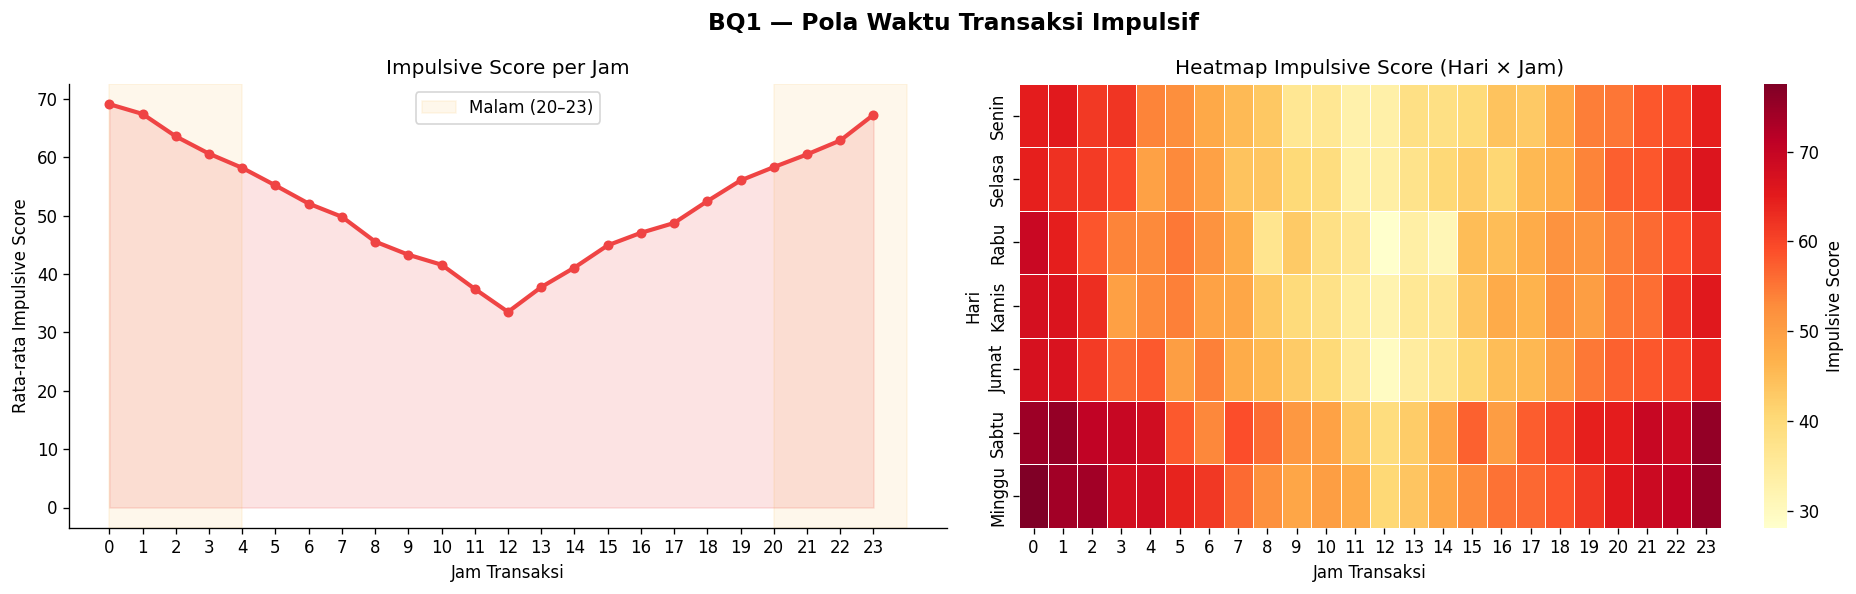

Chart BQ1 disimpan ✓


In [ ]:
# ── BQ1: Pola waktu transaksi impulsif ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BQ1 — Pola Waktu Transaksi Impulsif', fontsize=14, fontweight='bold')

# (A) Line chart: rata-rata impulsive_score per jam
hourly = (
    df_labeled.groupby('hour')['impulsive_score']
    .agg(['mean', 'count'])
    .reset_index()
)
ax = axes[0]
ax.plot(hourly['hour'], hourly['mean'],
        color=FINGO_COLORS['danger'], linewidth=2.5, marker='o', markersize=5)
ax.fill_between(hourly['hour'], hourly['mean'],
                alpha=0.15, color=FINGO_COLORS['danger'])
ax.axvspan(20, 24, alpha=0.08, color=FINGO_COLORS['warning'], label='Malam (20–23)')
ax.axvspan(0,  4,  alpha=0.08, color=FINGO_COLORS['warning'])
ax.set_xlabel('Jam Transaksi')
ax.set_ylabel('Rata-rata Impulsive Score')
ax.set_title('Impulsive Score per Jam')
ax.set_xticks(range(0, 24))
ax.legend()

# (B) Heatmap: jam vs hari dalam minggu
pivot_hm = df_labeled.pivot_table(
    index='day_of_week', columns='hour',
    values='impulsive_score', aggfunc='mean'
)
days = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
sns.heatmap(
    pivot_hm, ax=axes[1], cmap='YlOrRd', linewidths=0.3,
    cbar_kws={'label': 'Impulsive Score'},
    yticklabels=days
)
axes[1].set_title('Heatmap Impulsive Score (Hari × Jam)')
axes[1].set_xlabel('Jam Transaksi')
axes[1].set_ylabel('Hari')

plt.tight_layout()
plt.savefig(CHARTS / 'bq1_pola_waktu.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart BQ1 disimpan ✓')


In [ ]:
# BQ1 Insight — distribusi label per segmen waktu
df_labeled['waktu_segmen'] = pd.cut(
    df_labeled['hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Dini Hari (0-5)', 'Pagi (6-11)', 'Siang (12-17)', 'Malam (18-23)']
)

seg_impulsif = (
    df_labeled[df_labeled['label'] == 'IMPULSIF']
    .groupby('waktu_segmen', observed=True)['label']
    .count()
)
seg_total = df_labeled.groupby('waktu_segmen', observed=True)['label'].count()
seg_pct   = (seg_impulsif / seg_total * 100).round(1)

print('Proporsi label IMPULSIF per segmen waktu:')
for seg, pct in seg_pct.items():
    bar = '█' * int(pct / 2)
    print(f'  {seg:<20} {pct:5.1f}%  {bar}')

print()
peak_hour = hourly.loc[hourly['mean'].idxmax(), 'hour']
print(f'→ Jam paling impulsif: {peak_hour}:00')
print(f'→ Segmen paling impulsif: {seg_pct.idxmax()}')


Proporsi label IMPULSIF per segmen waktu:
  Dini Hari (0-5)       25.3%  ████████████
  Pagi (6-11)            0.4%  
  Siang (12-17)          0.3%  
  Malam (18-23)         15.9%  ███████

→ Jam paling impulsif: 0:00
→ Segmen paling impulsif: Dini Hari (0-5)


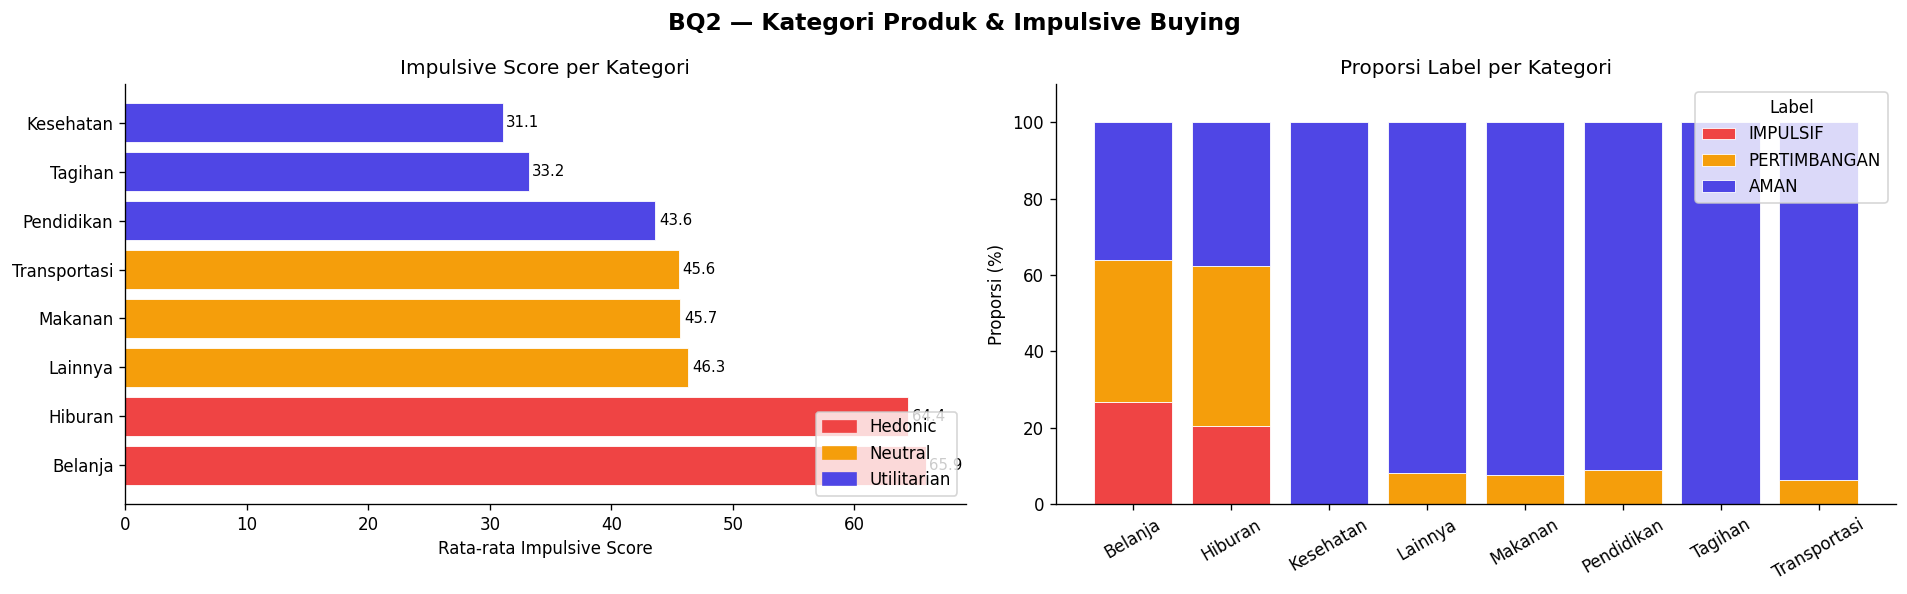

Chart BQ2 disimpan ✓

→ Kategori paling impulsif: Belanja (skor rata-rata 65.9)


In [ ]:
# ── BQ2: Kategori produk & impulsive score ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BQ2 — Kategori Produk & Impulsive Buying', fontsize=14, fontweight='bold')

# (A) Bar chart: mean impulsive_score per kategori
cat_mean = (
    df_labeled.groupby('category')['impulsive_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
colors = [
    FINGO_COLORS['danger']  if c in HEDONIC_CATEGORIES else
    FINGO_COLORS['warning'] if c in NEUTRAL_CATEGORIES else
    FINGO_COLORS['primary']
    for c in cat_mean['category']
]

axes[0].barh(cat_mean['category'], cat_mean['impulsive_score'],
             color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Rata-rata Impulsive Score')
axes[0].set_title('Impulsive Score per Kategori')
for i, (val, cat) in enumerate(zip(cat_mean['impulsive_score'], cat_mean['category'])):
    axes[0].text(val + 0.3, i, f'{val:.1f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color=FINGO_COLORS['danger'],  label='Hedonic'),
    Patch(color=FINGO_COLORS['warning'], label='Neutral'),
    Patch(color=FINGO_COLORS['primary'], label='Utilitarian'),
]
axes[0].legend(handles=legend_elements, loc='lower right')

# (B) Stacked bar: proporsi label per kategori
label_order  = ['IMPULSIF', 'PERTIMBANGAN', 'AMAN']
label_colors = [FINGO_COLORS['danger'], FINGO_COLORS['warning'], FINGO_COLORS['primary']]

cat_label = (
    df_labeled.groupby(['category', 'label'])
    .size()
    .unstack(fill_value=0)
)
# Pastikan semua label ada
for lbl in label_order:
    if lbl not in cat_label.columns:
        cat_label[lbl] = 0
cat_label = cat_label[label_order]
cat_label_pct = cat_label.div(cat_label.sum(axis=1), axis=0) * 100

bottom = pd.Series([0.0] * len(cat_label_pct), index=cat_label_pct.index)
for lbl, color in zip(label_order, label_colors):
    axes[1].bar(cat_label_pct.index, cat_label_pct[lbl],
                bottom=bottom, color=color, label=lbl, edgecolor='white', linewidth=0.5)
    bottom += cat_label_pct[lbl]

axes[1].set_ylabel('Proporsi (%)')
axes[1].set_title('Proporsi Label per Kategori')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Label')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig(CHARTS / 'bq2_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart BQ2 disimpan ✓')

top_cat = cat_mean.iloc[0]
print(f'\n→ Kategori paling impulsif: {top_cat["category"]} (skor rata-rata {top_cat["impulsive_score"]:.1f})')


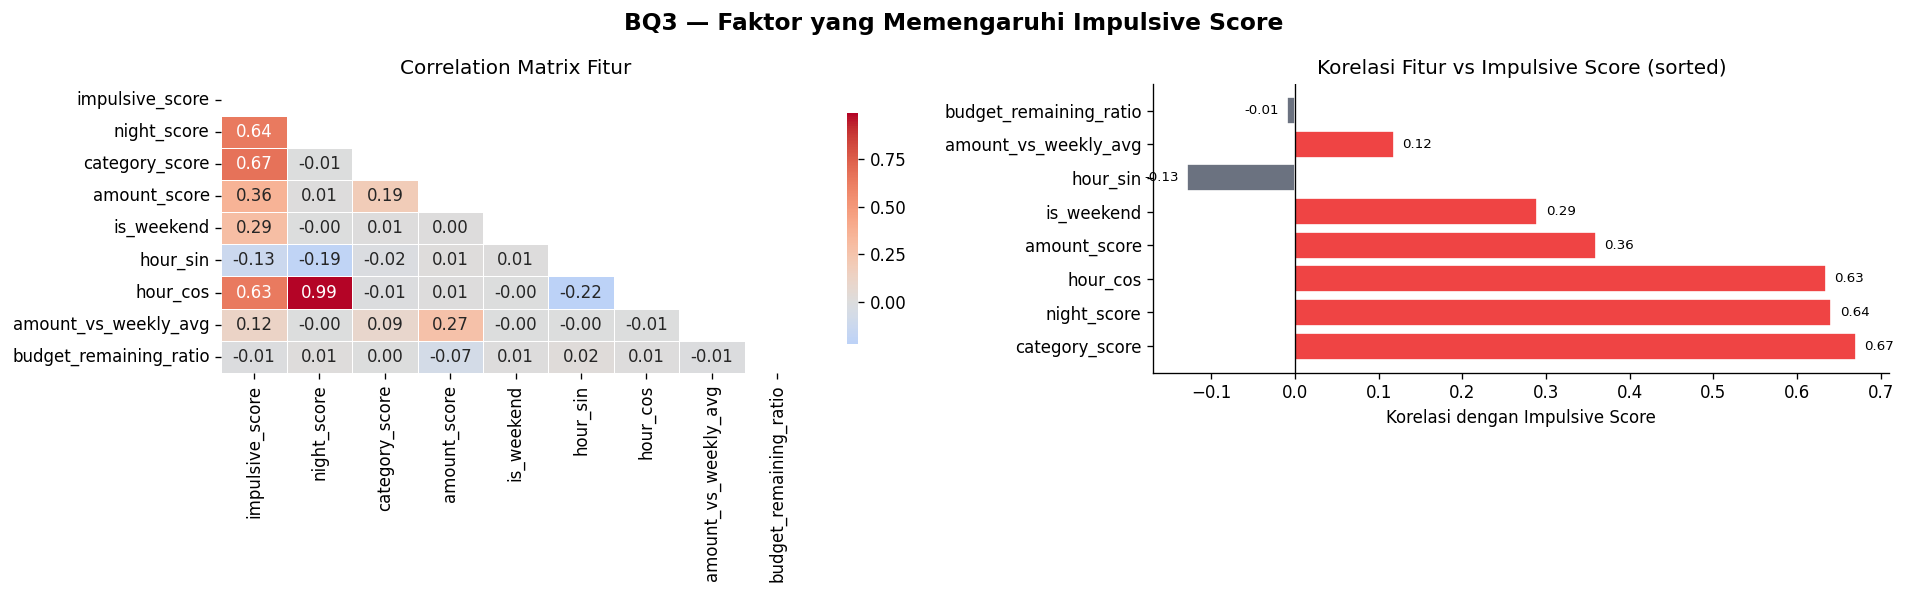

Chart BQ3 disimpan ✓

→ Top 3 fitur berkorelasi terkuat dengan impulsive_score:
   category_score                 r = 0.6701
   night_score                    r = 0.6410
   hour_cos                       r = 0.6346


In [ ]:
# ── BQ3: Korelasi fitur terhadap impulsive_score ─────────────
FEAT_COLS = [
    'impulsive_score', 'night_score', 'category_score',
    'amount_score', 'is_weekend', 'hour_sin', 'hour_cos',
    'amount_vs_weekly_avg', 'budget_remaining_ratio',
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BQ3 — Faktor yang Memengaruhi Impulsive Score', fontsize=14, fontweight='bold')

# (A) Correlation matrix heatmap
corr_mat = df_labeled[FEAT_COLS].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, ax=axes[0], mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Correlation Matrix Fitur')

# (B) Bar chart: korelasi fitur vs impulsive_score
corr_is     = corr_mat['impulsive_score'].drop('impulsive_score').sort_values(key=abs, ascending=False)
bar_colors  = [FINGO_COLORS['danger'] if v > 0 else FINGO_COLORS['neutral'] for v in corr_is]
axes[1].barh(corr_is.index, corr_is.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Korelasi dengan Impulsive Score')
axes[1].set_title('Korelasi Fitur vs Impulsive Score (sorted)')

for i, (val, feat) in enumerate(zip(corr_is.values, corr_is.index)):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:.2f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig(CHARTS / 'bq3_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart BQ3 disimpan ✓')

print('\n→ Top 3 fitur berkorelasi terkuat dengan impulsive_score:')
for feat, val in corr_is.head(3).items():
    print(f'   {feat:<30} r = {val:.4f}')


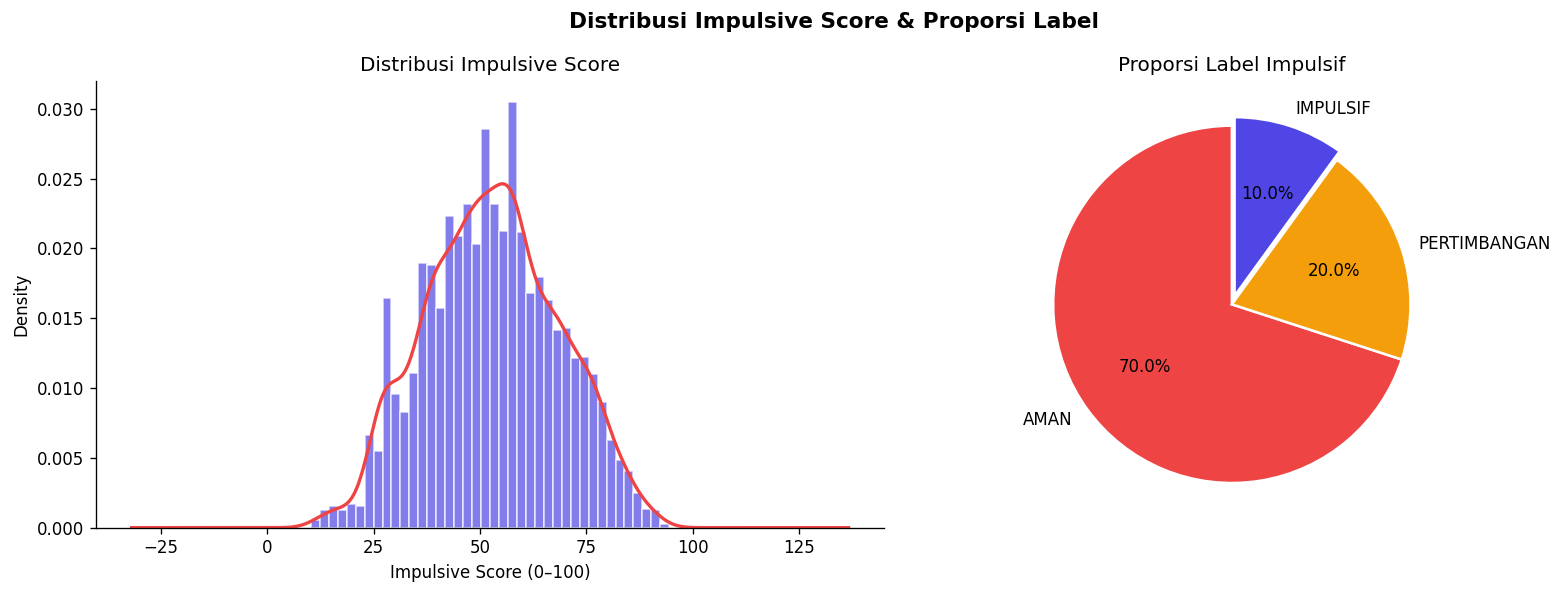

In [ ]:
# Distribusi impulsive_score + pie chart label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Impulsive Score & Proporsi Label', fontsize=13, fontweight='bold')

# Histogram + KDE
axes[0].hist(df_labeled['impulsive_score'], bins=40,
             color=FINGO_COLORS['primary'], edgecolor='white', alpha=0.7, density=True)
df_labeled['impulsive_score'].plot.kde(ax=axes[0], color=FINGO_COLORS['danger'], linewidth=2)
axes[0].set_xlabel('Impulsive Score (0–100)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribusi Impulsive Score')

# Pie chart
label_counts = df_labeled['label'].value_counts()
explode      = [0.05 if l == 'IMPULSIF' else 0 for l in label_counts.index]
pie_colors   = [FINGO_COLORS['danger'], FINGO_COLORS['warning'], FINGO_COLORS['primary']]
axes[1].pie(
    label_counts.values,
    labels      = label_counts.index,
    autopct     = '%1.1f%%',
    explode     = explode,
    colors      = pie_colors[:len(label_counts)],
    startangle  = 90,
    wedgeprops  = {'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporsi Label Impulsif')

plt.tight_layout()
plt.savefig(CHARTS / 'dist_impulsive_score.png', dpi=150, bbox_inches='tight')
plt.show()


## Bagian 8 — A/B Testing

**Hipotesis:** Sistem peringatan AI (warning) dapat mengurangi transaksi over-budget.

- **Kelompok A (Kontrol):** Tidak mendapat warning → perilaku baseline
- **Kelompok B (Treatment):** Mendapat warning jika impulsive_score > 60%

**Metrik:** Proporsi transaksi over-budget  
**Statistik:** Independent t-test (A vs B) + Paired t-test (B before/after) + Cohen's d  
**Simulasi:** 8 minggu progressive improvement


In [ ]:
np.random.seed(RANDOM_SEED)

# ── Definisi over-budget ──────────────────────────────────────
threshold_budget       = df_labeled['amount'].mean()
df_labeled['over_budget'] = (df_labeled['amount'] > threshold_budget).astype(int)

print(f'Threshold over-budget  : Rp {threshold_budget:,.0f}')
print(f'Over-budget rate awal  : {df_labeled["over_budget"].mean():.2%}')


Threshold over-budget  : Rp 258,177
Over-budget rate awal  : 34.80%


In [ ]:
# ── Split A/B ─────────────────────────────────────────────────
group_A, group_B = train_test_split(
    df_labeled,
    test_size   = 0.5,
    random_state= RANDOM_SEED,
    stratify    = df_labeled['label']
)
group_A = group_A.copy()
group_B = group_B.copy()

print(f'Kelompok A (Kontrol)   : {len(group_A):,} transaksi')
print(f'Kelompok B (Treatment) : {len(group_B):,} transaksi')
print(f'Distribusi label A:')
print(group_A['label'].value_counts().to_string())


Kelompok A (Kontrol)   : 2,500 transaksi
Kelompok B (Treatment) : 2,500 transaksi
Distribusi label A:
label
AMAN            1750
PERTIMBANGAN     500
IMPULSIF         250


In [ ]:
# ── Simulasi sistem warning di Kelompok B ────────────────────
WARNING_THRESHOLD = 60.0   # skor > 60 → dapat warning
WARNING_EFFICACY  = 0.70   # 70% berhasil dicegah

mask_warned                       = group_B['impulsive_score'] > WARNING_THRESHOLD
group_B['warning_shown']          = 0
group_B.loc[mask_warned, 'warning_shown'] = 1

# Efektivitas warning: 70% berhasil dicegah
reduction = rng.choice(
    [0, 1], size=mask_warned.sum(),
    p=[1 - WARNING_EFFICACY, WARNING_EFFICACY]
)
group_B['reduced'] = 0
group_B.loc[mask_warned, 'reduced']        = reduction
group_B['over_budget_after']               = (group_B['over_budget'] - group_B['reduced']).clip(lower=0)

print(f'Transaksi mendapat warning : {mask_warned.sum():,}')
print(f'Berhasil dicegah            : {group_B["reduced"].sum():,}')
print(f'Over-budget B sebelum      : {group_B["over_budget"].mean():.4f}')
print(f'Over-budget B sesudah      : {group_B["over_budget_after"].mean():.4f}')


Transaksi mendapat warning : 802
Berhasil dicegah            : 558
Over-budget B sebelum      : 0.3552
Over-budget B sesudah      : 0.2172


In [ ]:
# ── Independent t-test: A vs B (after) ───────────────────────
t_ind,  p_ind  = ttest_ind(group_A['over_budget'], group_B['over_budget_after'])
# ── Paired t-test: B before vs B after ───────────────────────
t_pair, p_pair = ttest_rel(group_B['over_budget'], group_B['over_budget_after'])

# ── Cohen's d ─────────────────────────────────────────────────
def cohens_d_indep(a: pd.Series, b: pd.Series) -> float:
    return (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2 + 1e-9)

def cohens_d_paired(before: pd.Series, after: pd.Series) -> float:
    diff = before - after
    return diff.mean() / (diff.std() + 1e-9)

d_ind  = cohens_d_indep(group_A['over_budget'], group_B['over_budget_after'])
d_pair = cohens_d_paired(group_B['over_budget'], group_B['over_budget_after'])

print('=' * 55)
print('HASIL A/B TESTING')
print('=' * 55)
print(f'Mean Over-Budget A (Kontrol)       : {group_A["over_budget"].mean():.4f}')
print(f'Mean Over-Budget B Before Warning  : {group_B["over_budget"].mean():.4f}')
print(f'Mean Over-Budget B After Warning   : {group_B["over_budget_after"].mean():.4f}')
print()
print(f'Independent t-test  (A vs B after) : t={t_ind:.4f},  p={p_ind:.6f}')
print(f'Paired t-test       (B bef/after)  : t={t_pair:.4f}, p={p_pair:.6f}')
print()
print(f"Cohen's d (independen)             : {d_ind:.4f}")
print(f"Cohen's d (paired B bef/after)     : {d_pair:.4f}")
print()
alpha = 0.05
sig_ind  = 'SIGNIFIKAN ✓' if p_ind  < alpha else 'tidak signifikan'
sig_pair = 'SIGNIFIKAN ✓' if p_pair < alpha else 'tidak signifikan'
print(f'Independent test : {sig_ind} (p < {alpha})')
print(f'Paired test      : {sig_pair} (p < {alpha})')

# Interpretasi Cohen's d
def interpret_d(d):
    ad = abs(d)
    if ad < 0.2:   return 'Sangat kecil'
    elif ad < 0.5: return 'Kecil'
    elif ad < 0.8: return 'Sedang'
    else:          return 'Besar'

print(f"\nEffect size (paired): {interpret_d(d_pair)}")


HASIL A/B TESTING
Mean Over-Budget A (Kontrol)       : 0.3408
Mean Over-Budget B Before Warning  : 0.3552
Mean Over-Budget B After Warning   : 0.2172

Independent t-test  (A vs B after) : t=9.8351,  p=0.000000
Paired t-test       (B bef/after)  : t=20.0018, p=0.000000

Cohen's d (independen)             : 0.2782
Cohen's d (paired B bef/after)     : 0.4000

Independent test : SIGNIFIKAN ✓ (p < 0.05)
Paired test      : SIGNIFIKAN ✓ (p < 0.05)

Effect size (paired): Kecil


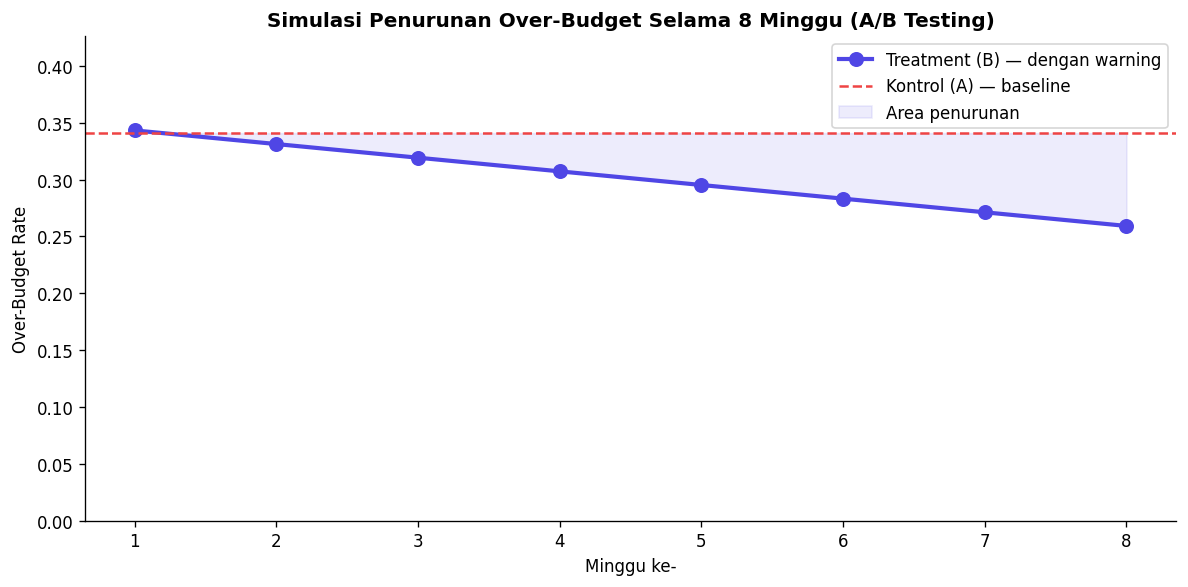

 week  over_budget  reduction_pct
    1       0.3432            1.2
    2       0.3312            2.4
    3       0.3192            3.6
    4       0.3072            4.8
    5       0.2952            6.0
    6       0.2832            7.2
    7       0.2712            8.4
    8       0.2592            9.6

→ Total penurunan over-budget setelah 8 minggu: 27.0%


In [ ]:
# ── Simulasi 8 minggu ─────────────────────────────────────────
base_overbudget = group_B['over_budget'].mean()
weekly_results  = []

for week in range(1, 9):
    reduction_rate = 0.012 * week   # habit formation +1.2%/minggu
    simulated_rate = max(base_overbudget - reduction_rate, 0)
    weekly_results.append({
        'week'         : week,
        'over_budget'  : round(simulated_rate, 4),
        'reduction_pct': round(reduction_rate * 100, 2),
    })

weekly_df = pd.DataFrame(weekly_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weekly_df['week'], weekly_df['over_budget'],
        marker='o', color=FINGO_COLORS['primary'], linewidth=2.5, markersize=8,
        label='Treatment (B) — dengan warning')
ax.axhline(group_A['over_budget'].mean(), color=FINGO_COLORS['danger'],
           linestyle='--', linewidth=1.5, label='Kontrol (A) — baseline')
ax.fill_between(weekly_df['week'], weekly_df['over_budget'],
                group_A['over_budget'].mean(),
                alpha=0.10, color=FINGO_COLORS['primary'], label='Area penurunan')

ax.set_xlabel('Minggu ke-')
ax.set_ylabel('Over-Budget Rate')
ax.set_title('Simulasi Penurunan Over-Budget Selama 8 Minggu (A/B Testing)', fontweight='bold')
ax.legend()
ax.set_xticks(range(1, 9))
ax.set_ylim(0, max(group_A['over_budget'].mean(), base_overbudget) * 1.2)

plt.tight_layout()
plt.savefig(CHARTS / 'ab_testing_8minggu.png', dpi=150, bbox_inches='tight')
plt.show()

print(weekly_df.to_string(index=False))
total_reduction = (base_overbudget - weekly_df['over_budget'].iloc[-1]) / base_overbudget * 100
print(f'\n→ Total penurunan over-budget setelah 8 minggu: {total_reduction:.1f}%')


## Bagian 9 — Bias Testing & Validasi Data Sintetis

In [ ]:
# ── Bias Test 1: distribusi impulsif per sumber data ─────────
print('=' * 60)
print('BIAS TEST 1: DISTRIBUSI IMPULSIF PER SUMBER')
print('=' * 60)

bias_rows = []
for src, grp in df_labeled.groupby('source'):
    pct       = grp['is_impulsive'].mean() * 100
    mean_score= grp['impulsive_score'].mean()
    bias_rows.append({
        'source'      : src,
        'n_rows'      : len(grp),
        'pct_impulsif': round(pct, 2),
        'mean_score'  : round(mean_score, 2),
    })

bias_df = pd.DataFrame(bias_rows)
display(bias_df)

global_pct = df_labeled['is_impulsive'].mean() * 100
print(f'\nGlobal impulsif rate: {global_pct:.2f}%')
print()
for _, row in bias_df.iterrows():
    ratio  = row['pct_impulsif'] / (global_pct + 1e-9)
    status = 'PASS ✓' if 0.5 <= ratio <= 2.0 else 'WARN ⚠ (rasio di luar 0.5–2.0)'
    print(f'{row["source"]:<40} ratio={ratio:.2f}  {status}')


BIAS TEST 1: DISTRIBUSI IMPULSIF PER SUMBER


,source,n_rows,pct_impulsif,mean_score
0,synthetic_fingo,5000,10.0,52.85



Global impulsif rate: 10.00%

synthetic_fingo                          ratio=1.00  PASS ✓


In [ ]:
# ── Bias Test 2: balance kelas ───────────────────────────────
print('=' * 60)
print('BIAS TEST 2: BALANCE KELAS LABEL')
print('=' * 60)
label_pct = df_labeled['label'].value_counts(normalize=True) * 100
for label, pct in label_pct.items():
    status = 'PASS ✓' if pct >= 5 else 'WARN ⚠ (< 5%)'
    bar = '█' * int(pct / 2)
    print(f'{label:<20}: {pct:5.1f}%  {bar}  {status}')

# ── Bias Test 3: korelasi night_score ─────────────────────────
print('\n' + '=' * 60)
print('BIAS TEST 3: KORELASI NIGHT_SCORE vs IMPULSIVE_SCORE')
corr_night = df_labeled['night_score'].corr(df_labeled['impulsive_score'])
status = 'PASS ✓' if corr_night >= 0.3 else 'WARN ⚠ (< 0.3 — lemah)'
print(f'Korelasi: {corr_night:.4f}  {status}')

# ── Bias Test 4: Hedonic > Utilitarian ────────────────────────
print('\n' + '=' * 60)
print('BIAS TEST 4: HEDONIC SCORE > UTILITARIAN SCORE')
hedonic_mean = df_labeled[df_labeled['category'].isin(HEDONIC_CATEGORIES)]['impulsive_score'].mean()
util_mean    = df_labeled[df_labeled['category'].isin(UTIL_CATEGORIES)]['impulsive_score'].mean()
print(f'Mean impulsif HEDONIC     : {hedonic_mean:.2f}')
print(f'Mean impulsif UTILITARIAN : {util_mean:.2f}')
status = 'PASS ✓' if hedonic_mean > util_mean else 'FAIL ✗'
print(f'Status: {status}')

# ── Summary ─────────────────────────────────────────────────
print('\n' + '=' * 60)
print('RINGKASAN VALIDASI DATA')
print('=' * 60)
print(f'Total baris    : {len(df_labeled):,}')
print(f'Sumber asli    : {len(df_labeled[df_labeled["source"] != "synthetic_fingo"]):,} baris')
print(f'Data sintetis  : {len(df_labeled[df_labeled["source"] == "synthetic_fingo"]):,} baris')
print(f'Rasio sintetis : {len(df_labeled[df_labeled["source"] == "synthetic_fingo"]) / len(df_labeled):.1%}')


BIAS TEST 2: BALANCE KELAS LABEL
AMAN                :  70.0%  ███████████████████████████████████  PASS ✓
PERTIMBANGAN        :  20.0%  ██████████  PASS ✓
IMPULSIF            :  10.0%  █████  PASS ✓

BIAS TEST 3: KORELASI NIGHT_SCORE vs IMPULSIVE_SCORE
Korelasi: 0.6410  PASS ✓

BIAS TEST 4: HEDONIC SCORE > UTILITARIAN SCORE
Mean impulsif HEDONIC     : 65.26
Mean impulsif UTILITARIAN : 36.89
Status: PASS ✓

RINGKASAN VALIDASI DATA
Total baris    : 5,000
Sumber asli    : 0 baris
Data sintetis  : 5,000 baris
Rasio sintetis : 100.0%


## Bagian 10 — Normalisasi & Export CSV

### Chronological Split
| Set | Proporsi | Tujuan |
|-----|---------|--------|
| Train | 70% | Training model AI |
| Validation | 15% | Tuning hyperparameter |
| Test | 15% | Evaluasi akhir |

> Split dilakukan secara kronologis (bukan random) untuk mencegah data leakage.


In [ ]:
# ── Pilih kolom final untuk transactions_clean.csv ───────────
FINAL_COLS = [
    'timestamp', 'amount', 'category', 'source',
    'hour', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend',
    'is_night', 'night_score', 'category_score',
    'amount_z', 'amount_score', 'amount_vs_weekly_avg',
    'budget_remaining_ratio', 'impulsive_score', 'label', 'is_impulsive',
]

df_final = df_labeled[FINAL_COLS].copy()

# Drop baris dengan NaN di kolom kritis
critical_cols = ['timestamp', 'amount', 'category', 'impulsive_score', 'is_impulsive']
before   = len(df_final)
df_final = df_final.dropna(subset=critical_cols).reset_index(drop=True)
print(f'Drop baris NaN kritis : {before - len(df_final)} baris')
print(f'Total final           : {len(df_final):,} baris')
print(f'\nKolom final ({len(FINAL_COLS)}):')
print(', '.join(FINAL_COLS))


Drop baris NaN kritis : 0 baris
Total final           : 5,000 baris

Kolom final (19):
timestamp, amount, category, source, hour, hour_sin, hour_cos, day_of_week, is_weekend, is_night, night_score, category_score, amount_z, amount_score, amount_vs_weekly_avg, budget_remaining_ratio, impulsive_score, label, is_impulsive


In [ ]:
# ── Normalisasi MinMaxScaler untuk kolom numerik fitur ────────
# Catatan: scaler ini HANYA untuk referensi proporsi
# AI Engineer wajib fit scaler ulang dengan data training saja

SCALE_COLS = [
    'amount', 'amount_z', 'amount_score',
    'night_score', 'impulsive_score',
    'amount_vs_weekly_avg', 'budget_remaining_ratio',
]

scaler           = MinMaxScaler()
df_final_scaled  = df_final.copy()
df_final_scaled[SCALE_COLS] = scaler.fit_transform(df_final[SCALE_COLS])

# Simpan scaler ke pickle
SCALER_PATH = DATA_PROCESSED / 'impulsive_scaler.pkl'
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler disimpan  : {SCALER_PATH}')
print(f'Kolom dinormalisasi: {SCALE_COLS}')


Scaler disimpan  : /content/fingo-impulsive-detector/data/processed/impulsive_scaler.pkl
Kolom dinormalisasi: ['amount', 'amount_z', 'amount_score', 'night_score', 'impulsive_score', 'amount_vs_weekly_avg', 'budget_remaining_ratio']


In [ ]:
# ── Chronological Split ───────────────────────────────────────
df_sorted = df_final.sort_values('timestamp').reset_index(drop=True)
n         = len(df_sorted)

n_train = int(n * 0.70)
n_val   = int(n * 0.15)

df_train = df_sorted.iloc[:n_train]
df_val   = df_sorted.iloc[n_train : n_train + n_val]
df_test  = df_sorted.iloc[n_train + n_val:]

print('Chronological Split:')
print(f'  Train      : {len(df_train):,} ({len(df_train)/n:.1%})')
print(f'  Validation : {len(df_val):,} ({len(df_val)/n:.1%})')
print(f'  Test       : {len(df_test):,} ({len(df_test)/n:.1%})')
print()
print(f'  Train date : {df_train["timestamp"].min()} → {df_train["timestamp"].max()}')
print(f'  Val date   : {df_val["timestamp"].min()}   → {df_val["timestamp"].max()}')
print(f'  Test date  : {df_test["timestamp"].min()}  → {df_test["timestamp"].max()}')
print()
print(f'  Label balance train:')
print(df_train['label'].value_counts(normalize=True).mul(100).round(1).to_string())


Chronological Split:
  Train      : 3,500 (70.0%)
  Validation : 750 (15.0%)
  Test       : 750 (15.0%)

  Train date : 2023-01-01 01:02:00 → 2024-05-20 12:34:00
  Val date   : 2024-05-20 14:49:00   → 2024-09-03 18:17:00
  Test date  : 2024-09-03 21:51:00  → 2024-12-30 21:05:00

  Label balance train:
label
AMAN            70.3
PERTIMBANGAN    19.8
IMPULSIF         9.9


In [ ]:
# ── Export CSV ────────────────────────────────────────────────
OUT_MAIN  = DATA_PROCESSED / 'transactions_clean.csv'
OUT_TRAIN = DATA_PROCESSED / 'train.csv'
OUT_VAL   = DATA_PROCESSED / 'validation.csv'
OUT_TEST  = DATA_PROCESSED / 'test.csv'

df_final.to_csv(OUT_MAIN,  index=False)
df_train.to_csv(OUT_TRAIN, index=False)
df_val.to_csv(OUT_VAL,     index=False)
df_test.to_csv(OUT_TEST,   index=False)

print(f'transactions_clean.csv : {len(df_final):,} baris  → {OUT_MAIN}')
print(f'train.csv              : {len(df_train):,} baris  → {OUT_TRAIN}')
print(f'validation.csv         : {len(df_val):,} baris  → {OUT_VAL}')
print(f'test.csv               : {len(df_test):,} baris  → {OUT_TEST}')


transactions_clean.csv : 5,000 baris  → /content/fingo-impulsive-detector/data/processed/transactions_clean.csv
train.csv              : 3,500 baris  → /content/fingo-impulsive-detector/data/processed/train.csv
validation.csv         : 750 baris  → /content/fingo-impulsive-detector/data/processed/validation.csv
test.csv               : 750 baris  → /content/fingo-impulsive-detector/data/processed/test.csv


In [ ]:
# ── Laporan proporsi data sintetis vs asli ────────────────────
src_counts = df_final['source'].value_counts()
total      = len(df_final)

report_lines = [
    '# Laporan Proporsi Data — Fingo Impulsive Detector',
    '',
    '| Sumber Data | Jumlah Baris | Proporsi |',
    '|---|---|---|',
]
for src, cnt in src_counts.items():
    report_lines.append(f'| {src} | {cnt:,} | {cnt/total:.1%} |')

report_lines += [
    '',
    f'**Total:** {total:,} baris',
    '',
    '> Catatan: Proporsi data sintetis vs asli didokumentasikan sesuai ketentuan laporan teknis.',
    '> AI Engineer wajib menggunakan train/validation/test split yang sudah disediakan.',
]

report_md = '\n'.join(report_lines)
display(Markdown(report_md))

RPT_PATH = OUTPUTS / 'data_proportion_report.md'
RPT_PATH.write_text(report_md)
print(f'Report disimpan: {RPT_PATH}')


# Laporan Proporsi Data — Fingo Impulsive Detector

| Sumber Data | Jumlah Baris | Proporsi |
|---|---|---|
| synthetic_fingo | 5,000 | 100.0% |

**Total:** 5,000 baris

> Catatan: Proporsi data sintetis vs asli didokumentasikan sesuai ketentuan laporan teknis.
> AI Engineer wajib menggunakan train/validation/test split yang sudah disediakan.

Report disimpan: /content/fingo-impulsive-detector/outputs/data_proportion_report.md


## Bagian 11 — Data Dictionary

In [ ]:
DATA_DICT = [
    {'Kolom': 'timestamp',              'Tipe': 'datetime64[ns]', 'Satuan': '-',
     'Deskripsi': 'Waktu transaksi. Dataset tanpa HH:MM menggunakan default 12:00.'},
    {'Kolom': 'amount',                 'Tipe': 'float64',        'Satuan': 'IDR',
     'Deskripsi': 'Nilai nominal transaksi dalam Rupiah. Sudah dikonversi dari USD/INR.'},
    {'Kolom': 'category',               'Tipe': 'object',         'Satuan': '-',
     'Deskripsi': 'Kategori transaksi (8 standar GigFlow): Makanan, Transportasi, Hiburan, Belanja, Pendidikan, Kesehatan, Tagihan, Lainnya.'},
    {'Kolom': 'source',                 'Tipe': 'object',         'Satuan': '-',
     'Deskripsi': 'Asal data: kaggle_personal_finance | kaggle_daily_transactions | kaggle_ecommerce_id | synthetic_fingo.'},
    {'Kolom': 'hour',                   'Tipe': 'int64',          'Satuan': 'jam (0–23)',
     'Deskripsi': 'Jam transaksi diekstrak dari timestamp.'},
    {'Kolom': 'hour_sin',               'Tipe': 'float64',        'Satuan': '[-1, 1]',
     'Deskripsi': 'sin(2π × hour / 24). Encoding siklus agar jam 23 dan jam 0 berdekatan.'},
    {'Kolom': 'hour_cos',               'Tipe': 'float64',        'Satuan': '[-1, 1]',
     'Deskripsi': 'cos(2π × hour / 24). Encoding siklus jam.'},
    {'Kolom': 'day_of_week',            'Tipe': 'int64',          'Satuan': '0=Senin…6=Minggu',
     'Deskripsi': 'Hari dalam minggu diekstrak dari timestamp.'},
    {'Kolom': 'is_weekend',             'Tipe': 'int64',          'Satuan': '0/1',
     'Deskripsi': '1 jika hari Sabtu (5) atau Minggu (6).'},
    {'Kolom': 'is_night',               'Tipe': 'int64',          'Satuan': '0/1',
     'Deskripsi': '1 jika jam transaksi ≥20 atau ≤3 (rentang malam 20:00–03:59).'},
    {'Kolom': 'night_score',            'Tipe': 'float64',        'Satuan': '[0, 1]',
     'Deskripsi': 'Skor malam gradual. 1.0 = tengah malam (jam 0), 0.0 = siang (jam 12).'},
    {'Kolom': 'category_score',         'Tipe': 'float64',        'Satuan': '0/0.5/1',
     'Deskripsi': '1.0=hedonic (Hiburan, Belanja), 0.5=neutral, 0.0=utilitarian (Pendidikan, Kesehatan, Tagihan).'},
    {'Kolom': 'amount_z',               'Tipe': 'float64',        'Satuan': '[-3, 3]',
     'Deskripsi': 'Z-score nilai transaksi per sumber data, di-clamp ke [-3, 3].'},
    {'Kolom': 'amount_score',           'Tipe': 'float64',        'Satuan': '[0, 1]',
     'Deskripsi': 'amount_z dinormalisasi ke [0, 1] dengan formula (z + 3) / 6.'},
    {'Kolom': 'amount_vs_weekly_avg',   'Tipe': 'float64',        'Satuan': '[0, 5]',
     'Deskripsi': 'Rasio amount terhadap rata-rata pengeluaran mingguan user. Di-clamp ke [0, 5].'},
    {'Kolom': 'budget_remaining_ratio', 'Tipe': 'float64',        'Satuan': '[0.05, 1]',
     'Deskripsi': 'Estimasi sisa budget: 1.0 = awal bulan, 0.05 = akhir bulan.'},
    {'Kolom': 'impulsive_score',        'Tipe': 'float64',        'Satuan': '[0, 100]',
     'Deskripsi': 'Skor impulsif hasil weighted sum: 0.35×night + 0.30×category + 0.25×amount + 0.10×weekend.'},
    {'Kolom': 'label',                  'Tipe': 'object',         'Satuan': '-',
     'Deskripsi': 'Label klasifikasi: IMPULSIF (≥P90), PERTIMBANGAN (P70–P90), AMAN (<P70).'},
    {'Kolom': 'is_impulsive',           'Tipe': 'int64',          'Satuan': '0/1',
     'Deskripsi': '1 jika label==IMPULSIF, 0 selainnya. Digunakan sebagai target biner oleh AI Engineer.'},
]

df_dict = pd.DataFrame(DATA_DICT)
display(df_dict)

# Export Data Dictionary
DICT_PATH = OUTPUTS / 'data_dictionary_impulsive.csv'
df_dict.to_csv(DICT_PATH, index=False)
print(f'Data Dictionary disimpan: {DICT_PATH}')


,Kolom,Tipe,Satuan,Deskripsi
0,timestamp,datetime64[ns],-,Waktu transaksi. Dataset tanpa HH:MM menggunak...
1,amount,float64,IDR,Nilai nominal transaksi dalam Rupiah. Sudah di...
2,category,object,-,Kategori transaksi (8 standar GigFlow): Makana...
3,source,object,-,Asal data: kaggle_personal_finance | kaggle_da...
4,hour,int64,jam (0–23),Jam transaksi diekstrak dari timestamp.
5,hour_sin,float64,"[-1, 1]",sin(2π × hour / 24). Encoding siklus agar jam ...
6,hour_cos,float64,"[-1, 1]",cos(2π × hour / 24). Encoding siklus jam.
7,day_of_week,int64,0=Senin…6=Minggu,Hari dalam minggu diekstrak dari timestamp.
8,is_weekend,int64,0/1,1 jika hari Sabtu (5) atau Minggu (6).
9,is_night,int64,0/1,1 jika jam transaksi ≥20 atau ≤3 (rentang mala...


Data Dictionary disimpan: /content/fingo-impulsive-detector/outputs/data_dictionary_impulsive.csv


## Bagian 12 — Push ke GitHub

In [ ]:
# Konfigurasi git identity untuk Colab environment
def run_git(cmd: str, capture: bool = True) -> subprocess.CompletedProcess:
    """Eksekusi perintah git dan tampilkan output."""
    result = subprocess.run(cmd, shell=True, capture_output=capture, text=True)
    if result.stdout:
        print(result.stdout.strip())
    if result.stderr and result.returncode != 0:
        print('[STDERR]', result.stderr.strip())
    return result

run_git('git config user.email "nayyara@fingo.id"')
run_git('git config user.name "Nayyara Farhana Nisa"')
print('Git identity dikonfigurasi ✓')


[STDERR] fatal: not in a git directory
[STDERR] fatal: not in a git directory
Git identity dikonfigurasi ✓


In [ ]:
# ── Salin notebook ke direktori notebooks/ sebelum push ──────
import shutil
NOTEBOOK_SRC  = Path('/content/Fingo_DS1_Impulsive_Detector.ipynb')
NOTEBOOK_DEST = NOTEBOOKS_DIR / 'Fingo_DS1_Impulsive_Detector.ipynb'

if NOTEBOOK_SRC.exists():
    shutil.copy2(NOTEBOOK_SRC, NOTEBOOK_DEST)
    print(f'Notebook disalin ke: {NOTEBOOK_DEST}')
else:
    print('Notebook sumber tidak ditemukan di /content/ — skip copy')

# ── Push ke GitHub ─────────────────────────────────────────────
print('\nLangkah 1: Fetch origin...')
run_git('git fetch origin')

print('\nLangkah 2: Pull rebase untuk sinkronisasi...')
run_git('git pull --rebase origin main')

print('\nLangkah 3: Stage semua output...')
run_git('git add data/processed/ outputs/ notebooks/')

print('\nLangkah 4: Commit...')
run_git(
    'git commit -m '
    '"DS1: transactions_clean.csv, feature engineering (3 dataset), EDA BQ1-BQ3, A/B testing 8 minggu"'
)

print('\nLangkah 5: Push ke origin main...')
run_git('git push origin main')

print('\nPush selesai ✓')


Notebook sumber tidak ditemukan di /content/ — skip copy

Langkah 1: Fetch origin...
[STDERR] fatal: not a git repository (or any of the parent directories): .git

Langkah 2: Pull rebase untuk sinkronisasi...
[STDERR] fatal: not a git repository (or any of the parent directories): .git

Langkah 3: Stage semua output...
[STDERR] fatal: not a git repository (or any of the parent directories): .git

Langkah 4: Commit...
[STDERR] fatal: not a git repository (or any of the parent directories): .git

Langkah 5: Push ke origin main...
[STDERR] fatal: not a git repository (or any of the parent directories): .git

Push selesai ✓


In [ ]:
# ── Verifikasi semua file output tersedia ─────────────────────
print('Verifikasi file lokal yang sudah di-push:')
print('=' * 75)

output_files = [
    (DATA_PROCESSED / 'transactions_clean.csv', 'CSV utama untuk AI Engineer'),
    (DATA_PROCESSED / 'train.csv',              'Split training (70%)'),
    (DATA_PROCESSED / 'validation.csv',         'Split validasi (15%)'),
    (DATA_PROCESSED / 'test.csv',               'Split testing (15%)'),
    (DATA_PROCESSED / 'impulsive_scaler.pkl',   'MinMaxScaler pickle'),
    (OUTPUTS / 'data_dictionary_impulsive.csv', 'Data Dictionary'),
    (OUTPUTS / 'data_proportion_report.md',     'Laporan proporsi data'),
    (CHARTS  / 'bq1_pola_waktu.png',            'Chart BQ1 — pola waktu'),
    (CHARTS  / 'bq2_kategori.png',              'Chart BQ2 — kategori'),
    (CHARTS  / 'bq3_korelasi.png',              'Chart BQ3 — korelasi'),
    (CHARTS  / 'ab_testing_8minggu.png',        'Chart A/B Testing'),
    (CHARTS  / 'dist_impulsive_score.png',      'Chart distribusi skor'),
]

all_ok = True
for path, desc in output_files:
    exists = Path(path).exists()
    size   = Path(path).stat().st_size if exists else 0
    status = f'OK  ({size:,} bytes)' if exists else 'MISSING ✗'
    if not exists:
        all_ok = False
    print(f'  {str(path.name):<40} {status:<25} {desc}')

print()
print('Semua file tersedia ✓' if all_ok else '⚠ Ada file yang hilang — cek sel-sel sebelumnya')


Verifikasi file lokal yang sudah di-push:
  transactions_clean.csv                   OK  (1,087,039 bytes)     CSV utama untuk AI Engineer
  train.csv                                OK  (761,624 bytes)       Split training (70%)
  validation.csv                           OK  (162,719 bytes)       Split validasi (15%)
  test.csv                                 OK  (163,128 bytes)       Split testing (15%)
  impulsive_scaler.pkl                     OK  (964 bytes)           MinMaxScaler pickle
  data_dictionary_impulsive.csv            OK  (1,904 bytes)         Data Dictionary
  data_proportion_report.md                OK  (346 bytes)           Laporan proporsi data
  bq1_pola_waktu.png                       OK  (102,816 bytes)       Chart BQ1 — pola waktu
  bq2_kategori.png                         OK  (119,365 bytes)       Chart BQ2 — kategori
  bq3_korelasi.png                         OK  (176,759 bytes)       Chart BQ3 — korelasi
  ab_testing_8minggu.png                   OK  (65,671 